In [1]:
# import necessary libraries
import os
import torch 
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle



from pathlib import Path


CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
    Path(r"/Users/vvvp./Desktop"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)





import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *


In [2]:
# 构建储层对象
class ReservoirParams:
    def __init__(self, **kwargs):
            # Reservoir parameters 
            self.h = 0.4
            self.theta_H = 90
            self.k_s_0 = 0
            self.phi = 45
            self.beta_prime = 35.13826524755751

            # Network parameters 
            self.Nvirt = 50
            self.m0 = 0.005288612874870094
            self.bias = True
            self.Nwarmup = 0
            self.verbose_repr = False

            self.params = {
                'theta': 0.34142235979698393,
                'gamma': 0.069274461903986,
                'delay_feedback': 0,
                'Nvirt': self.Nvirt,
                'length_warmup': self.Nwarmup,
                'warmup_sample': self.Nwarmup * self.Nvirt,
                'voltage_noise': False,
                'seed_voltage_noise': 1234,
                'delta_V': 0.1,
                'johnson_noise': False,
                'seed_johnson_noise': 1234,
                'mean_johnson_noise': 0.0000,
                'std_johnson_noise': 0.00001,
                'thermal_noise': False,
                'seed_thermal_noise': 1234,
                'lambda_ou': 1.0,
                'sigma_ou': 0.1
        }

            for key in ['h', 'theta_H', 'k_s_0', 'phi', 'beta_prime', 'Nvirt', 'm0', 'bias', 'Nwarmup']:
                if key in kwargs:
                    setattr(self, key, kwargs[key])

            
            if 'params' in kwargs and isinstance(kwargs['params'], dict):
                self.params.update(kwargs['params'])

    
    def update_params(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            if key in self.params:
                self.params[key] = value
            if not hasattr(self, key) and key not in self.params:
                raise AttributeError(f"ReservoirParams has no attribute or param key '{key}'")
            
    def print_params(self, verbose=False):
        if not verbose:
            print(f"ReservoirParams(h={self.h}, beta_prime={self.beta_prime}, Nvirt={self.Nvirt})")
        else:
            print(f"ReservoirParams detailed info:")
            print(f"  h = {self.h}")
            print(f"  theta_H = {self.theta_H}")
            print(f"  k_s_0 = {self.k_s_0}")
            print(f"  phi = {self.phi}")
            print(f"  beta_prime = {self.beta_prime}")
            print(f"  Nvirt = {self.Nvirt}")
            print(f"  m0 = {self.m0}")
            print(f"  bias = {self.bias}")
            print("  params dictionary:")
            for k, v in self.params.items():
                print(f"    {k}: {v}")

In [3]:
def MSE(pred, desired):
    return np.mean(np.square(np.subtract(pred, desired)))

def NRMSE(pred, y_test, spacer=0.001):
    return np.sqrt(MSE(pred, y_test) / np.var(y_test))

In [4]:
def generate_signal(I,washout = 50,seed=1234):
    '''
    Generate a i.i.d. signal sequence with a [-1,1] range
    '''
    if seed is not None:
        np.random.seed(seed)
        
    signal_sequence = np.random.uniform(-1,1,size = I)

    washed_signal = signal_sequence[washout:]

    # Convert to 2D array
    washed_signal = washed_signal.reshape(-1,1)

    # print(np.shape(washed_signal))

    return washed_signal

def RidgeRegression(states, target, l, bias=True):
    # Ensure numpy
    if torch.is_tensor(states):
        states = states.detach().cpu().numpy()
    if torch.is_tensor(target):
        target = target.detach().cpu().numpy()
    if bias==True:
        # Add bias to states
        bias = np.ones((len(states), 1))
        states = np.concatenate((bias, states), axis=1)
    # Setup matrices from inputs
    M1 = np.matmul(states.transpose(), target) 
    M2 = np.matmul(states.transpose(), states)
    # Perform ridge regression
    weights = np.matmul(np.linalg.pinv(M2+l*np.identity(len(M2))), M1)
    return weights

def linear_MC(signal, states, splits=[0.2, 0.8], delays=50):
    # ensure flat input signal
    signal = np.asarray(signal).flatten()
    # generate target signal from delayed input signal
    shift = np.zeros((len(signal), delays))
    for i in range(len(signal)-delays):
        i += delays
        shift[i, :] = signal[i-delays:i]
    # split data
    wash, Ytrain, Ytest = np.split(shift, [int(len(signal)*splits[0]), int(len(signal)*splits[1])])
    wash, Xtrain, Xtest = np.split(states, [int(len(signal)*splits[0]), int(len(signal)*splits[1])])
    # sweep over range of hyperparameters gamma to find optimal MC
    bestMC = 0
    gammas = np.logspace(-10, 0, 11)
    for gamma in gammas:
        # Calculate weights
        weights = RidgeRegression(Xtrain, Ytrain, gamma, bias=False)
        # Predict test states
        prediction = np.matmul(Xtest, weights)
        # Loop over all delays k and evaluate MC_k
        MC_k = np.zeros(delays)
        for k in range(delays):
            # Take prediction and target for each delay
            pred = prediction[:, k]
            targ = Ytest[:, k]
            # Set up matrix to calculate covariance
            M = pred, targ
            # Calculate covariance
            coVarM = np.cov(M)
            # Take cov(xy) 
            coVar = coVarM[0,1]
            # Measure the variance of the signals
            outVar = np.var(pred)
            targVar = np.var(targ)
            # Calculate the total variance of the raw target and the specific
            # target
            totVar = outVar*targVar
            # If the covariance coefficient is greater than 0.1, treat as better
            # than random guessing and add to MC_k outputs
            if coVar**2/totVar > 0.1:
                MC_k[k] = coVar**2/totVar
        # Account for floating point errors in MC
        MC_k[MC_k>1] = 1
        # Sum memory capacity over all delays
        MC = sum(MC_k)
        # If best reported MC, save data
        if MC > bestMC:
            bestMC = MC
    return bestMC

def RunSpnc(signal,Nin,Nout,Nvirt,m0,transform, params,**kwargs):
    '''
    Run a reservoir computer with the signal sequence
    '''
    snr = single_node_reservoir(Nin, Nout, Nvirt, m0, res=transform)

    fixed_mask = kwargs.get('fixed_mask', False)
    if fixed_mask==True:
        # print("Deterministic mask will be used")
        seed_mask = kwargs.get('seed_mask', 1234)
        if seed_mask>=0:
            # print(seed_mask)
            snr.M = fixed_seed_mask(Nin, Nvirt, m0, seed=seed_mask)
        else:
            # print("Max_sequences mask will be used")
            snr.M = max_sequences_mask(Nin, Nvirt, m0)
    
    # Run
    S,_ = snr.transform(signal,params)
    
    return S
    
def evaluate_MC(reservoir_params, signal_len = 550, **kwargs):

    signal = generate_signal(signal_len, seed=kwargs.get('seed', 1234))
    # 打印signal的前10个元素


    spn = spnc_anisotropy(
        reservoir_params.h,
        reservoir_params.theta_H,
        reservoir_params.k_s_0,
        reservoir_params.phi,
        reservoir_params.beta_prime,
        restart=True
    )

    transform = spn.gen_signal_slow_delayed_feedback

    Output = RunSpnc(
        signal,
        1,                 
        1,       
        reservoir_params.Nvirt,
        reservoir_params.m0,
        transform,
        reservoir_params.params,
        fixed_mask=True,
        seed_mask=1234
    )


    MC = linear_MC(signal, Output, splits=[0.2,0.6], delays=10)

    return MC

In [5]:
def gen_KR_GR_input(Nreadouts, Nwash=10, seed=1234):
    # set seed
    np.random.seed(seed)
    # generate KR inputs
    KR_inputs = np.random.ranf((Nreadouts, Nwash))
    # 打印KR_inputs
    # print('KR_inputs',KR_inputs)
    # print('shape of KR_inputs',np.shape(KR_inputs))

    GR_inputs = np.tile(np.random.ranf((10)), (Nreadouts,1))
    # print('GR_inputs',GR_inputs)
    # print('shape of GR_inputs',np.shape(GR_inputs))

    all_inputs = np.concatenate((KR_inputs, GR_inputs), axis=1)
    # 打印all_inputs的前10个元素
    # print('all_inputs',all_inputs)
    # print('shape of all_inputs',np.shape(all_inputs))
    return all_inputs


def Evaluate_KR_GR(states, Nreadouts, threshold=0.1):
    GR_states = states[:,-1,:]
    # print('GR_states',GR_states)
    # print('shape of GR_states',np.shape(GR_states))
    '''
    Change the last 7 columns to GR states, the rest are KR states
    '''
    KR_states = states[:,-11,:]
    # print('KR_states',KR_states)
    # print('shape of KR_states',np.shape(KR_states)) 
    
    uGR, sGR, vGR = np.linalg.svd(GR_states)
    uKR, sKR, vKR = np.linalg.svd(KR_states)
    KR = 0
    GR = 0
    for i in range(Nreadouts):
        if sGR[i]>threshold:
            GR += 1
        if sKR[i]>threshold:
            KR += 1
    return KR, GR, GR_states, KR_states

# ------------------------ Reservoir ----------------------------


In [34]:
def evaluate_KRandGR(reservoir_params, Nreadouts=50, Nwash=10, **kwargs):
    
    Nreadouts= reservoir_params.Nvirt

    inputs = gen_KR_GR_input(Nreadouts, Nwash, seed=1234)   # <--- 用Nreadouts
    outputs = []
    for input_row in inputs:
        input_row = input_row.reshape(-1, 1)
        spn = spnc_anisotropy(reservoir_params.h, reservoir_params.theta_H,
                              reservoir_params.k_s_0, reservoir_params.phi,
                              reservoir_params.beta_prime, restart=True)
        transforms = spn.gen_signal_slow_delayed_feedback
        output = RunSpnc(input_row, 1, 1, reservoir_params.Nvirt,
                         reservoir_params.m0, transforms, reservoir_params.params, fixed_mask=True, seed_mask=1234)
        outputs.append(output)
    # print('transformed outputs',outputs)
    # print('shape of transformed outputs',np.shape(outputs))
    States = np.stack(outputs, axis=0)
    # print('States',States[0])
    # print('shape of States',np.shape(States))
    Normalized_States = States/np.amax(States)
    # print('Normalized States',Normalized_States[0])
    # print('shape of Normalized States',np.shape(Normalized_States))
    KR, GR, GR_states, KR_states = Evaluate_KR_GR(States, Nreadouts, threshold=0.001)  # <--- 用Nreadouts
    return KR, GR, GR_states, KR_states, outputs, States, Normalized_States


In [7]:
def eva_narma10(reservoir_params: ReservoirParams, 
                        Ntrain: int = 2000, Ntest: int = 1000, seed_NARMA: int = 1234):
        """评估NARMA-10任务"""

        # 创建储层
        spn = spnc_anisotropy(
            h=reservoir_params.h,
            theta_H=reservoir_params.theta_H,
            k_s=reservoir_params.k_s_0,
            phi=reservoir_params.phi,
            beta_prime=reservoir_params.beta_prime,
            restart=True
        )

        transform = spn.gen_signal_slow_delayed_feedback
        
        # 运行NARMA-10任务
        (y_test, pred) = spnc_narma10(
            Ntrain,
            Ntest,
            reservoir_params.Nvirt,
            reservoir_params.m0,
            reservoir_params.bias,
            transform,
            reservoir_params.params,
            seed_NARMA=seed_NARMA,
            fixed_mask=True,
            seed_mask=1234,
            return_outputs=True,
        )
        
        # 计算NRMSE

        
        return y_test, pred

In [8]:
def eva_ti46(reservoir_params: ReservoirParams, 
                    speakers: ['f1','f2','f3','f4','f5']) -> float:
    """评估TI46任务"""
    
    # 创建储层
    spn = spnc_anisotropy(
        h=reservoir_params.h,
        theta_H=reservoir_params.theta_H,
        k_s=reservoir_params.k_s_0,
        phi=reservoir_params.phi,
        beta_prime=reservoir_params.beta_prime,
        restart=True
    )

    transform = spn.gen_signal_slow_delayed_feedback
    
    # 运行TI46任务
    accuracy = spnc_TI46(
        speakers,
        reservoir_params.Nvirt,
        reservoir_params.m0,
        reservoir_params.bias,
        transform,
        reservoir_params.params)
    
    return accuracy


### 以下cell是用来评估是否bestCQ对于任意namra10输入序列的反馈都是一样的

In [9]:
params_bestCQ = ReservoirParams(
        h=0.4, m0=0.006937322149792008, Nvirt=50, beta_prime=27.251620432439488,
        params={'theta': 0.01, 'gamma': 0.3663969812988086, 'Nvirt': 50}
    )

In [10]:
y_test, pred_1234 = eva_narma10(params_bestCQ, Ntrain=2000, Ntest=1000, seed_NARMA=1234)











Seed Training: 1234
len(x_train): 2000
error with zero =  0.025590136678639137
0.01224755838850576 1.000013157854191


In [15]:
# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE

# seed是1000以内的随机数
seed_NARMA = np.random.randint(0, 1000, 3)
params_dict = {}

# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE
for idx, i in enumerate(seed_NARMA):
    params = ReservoirParams(
        h=0.4, m0=0.006937322149792008, Nvirt=50, beta_prime=27.251620432439488,
        params={'theta': 0.01, 'gamma': 0.3663969812988086, 'Nvirt': 50}
    )

    y_test, pred = eva_narma10(params, Ntrain=2000, Ntest=1000, seed_NARMA=i)
    nrmse = NRMSE(pred,y_test)
    params_dict[idx] = {
        'seed_NARMA': i,
        'nrmse': nrmse,
        'y_test': y_test,
        'pred': pred
    }
    print(f"idx: {idx}, seed_NARMA: {i}, NRMSE: {nrmse}")








Seed Training: 1234
len(x_train): 2000
error with zero =  5.26428902232998
0.011002367355309656 1.0060783138695921
idx: 0, seed_NARMA: 260, NRMSE: 42.41701325173466
Seed Training: 1234
len(x_train): 2000
error with zero =  2.0590481326243655
0.01369482168111302 1.0019076301442738
idx: 1, seed_NARMA: 464, NRMSE: 511.1831438298664
Seed Training: 1234
len(x_train): 2000
error with zero =  19.10735517398901
0.01015276283533789 1.0001841787472225
idx: 2, seed_NARMA: 743, NRMSE: 231.25096056969974


### 画出trajectory图来看看

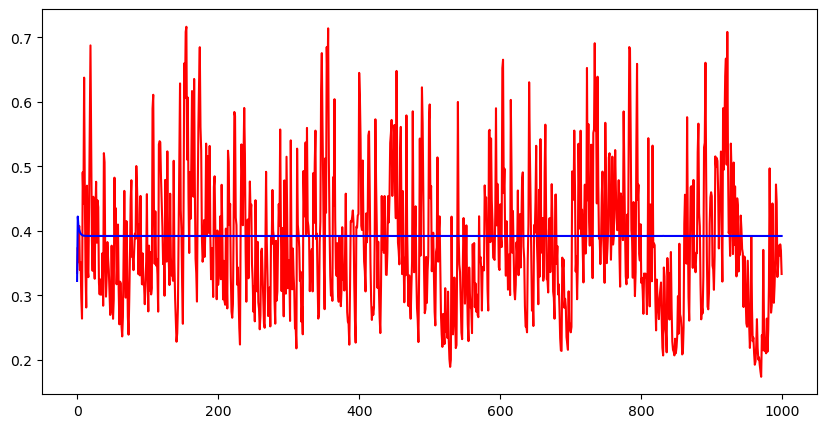

In [17]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict[0]['y_test'], color='red')
plt.plot(params_dict[0]['pred'], color='blue')
plt.show()  

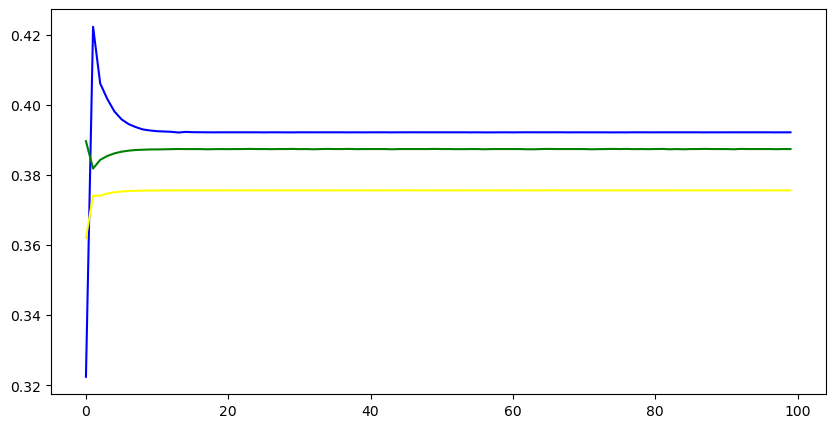

In [19]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict[0]['pred'][:100], color='blue')
plt.plot(params_dict[1]['pred'][:100], color='green')
plt.plot(params_dict[2]['pred'][:100], color='yellow')
plt.show()  

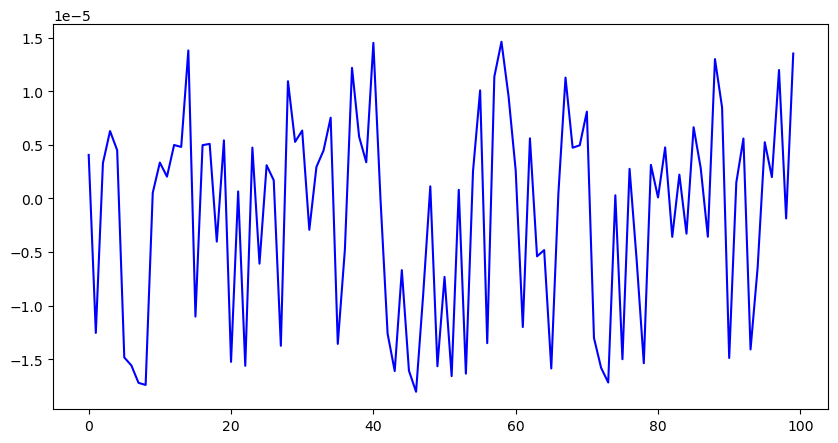

In [29]:
average = np.mean(params_dict[0]['pred'][100:])
difference = params_dict[0]['pred'] - average

plt.figure(figsize=(10, 5))
plt.plot(difference[100:200], color='blue')
plt.show()  










### 测试bestMC作为对比

In [20]:
params_bestMC = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=50, beta_prime=	50.0,
        params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 50}
    )

y_test_bestMC, pred_bestMC_1234 = eva_narma10(params_bestMC, Ntrain=2000, Ntest=1000, seed_NARMA=1234)

Seed Training: 1234
len(x_train): 2000
error with zero =  0.004568546087762927
0.011018730520634875 0.9485205315352864


In [21]:
# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE

# seed是1000以内的随机数
seed_NARMA = np.random.randint(0, 1000, 3)
params_dict_MC = {}

# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE
for idx, i in enumerate(seed_NARMA):
    params = ReservoirParams(
            h=0.4, m0=0.008, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 50}
        )

    y_test, pred = eva_narma10(params, Ntrain=2000, Ntest=1000, seed_NARMA=i)
    nrmse = NRMSE(pred,y_test)
    params_dict_MC[idx] = {
        'seed_NARMA': i,
        'nrmse': nrmse,
        'y_test': y_test,
        'pred': pred
    }
    print(f"idx: {idx}, seed_NARMA: {i}, NRMSE: {nrmse}")

Seed Training: 1234
len(x_train): 2000
error with zero =  0.004755069542823838
0.007168379906776746 0.7878163800176976
idx: 0, seed_NARMA: 907, NRMSE: 0.7878163800176976
Seed Training: 1234
len(x_train): 2000
error with zero =  0.004062858107774707
0.008025066737511879 0.7702494462236094
idx: 1, seed_NARMA: 204, NRMSE: 0.7702494462236094
Seed Training: 1234
len(x_train): 2000
error with zero =  0.006131437582124847
0.008893885864580217 0.8180110846429584
idx: 2, seed_NARMA: 570, NRMSE: 0.8180110846429584


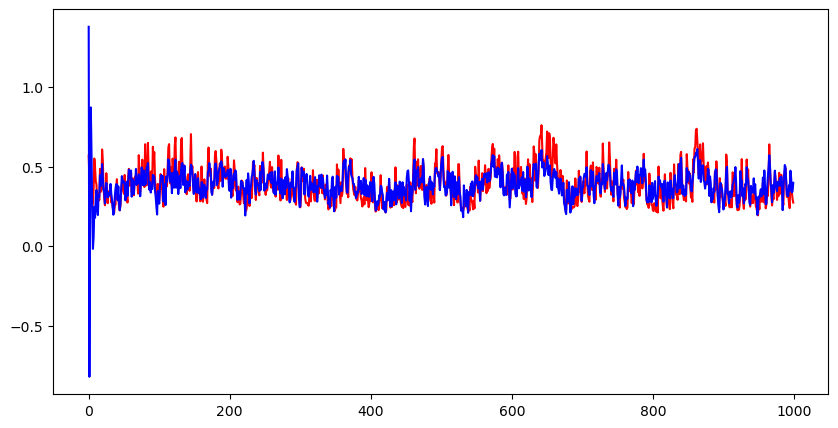

In [22]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_MC[0]['y_test'], color='red')
plt.plot(params_dict_MC[0]['pred'], color='blue')
plt.show()  

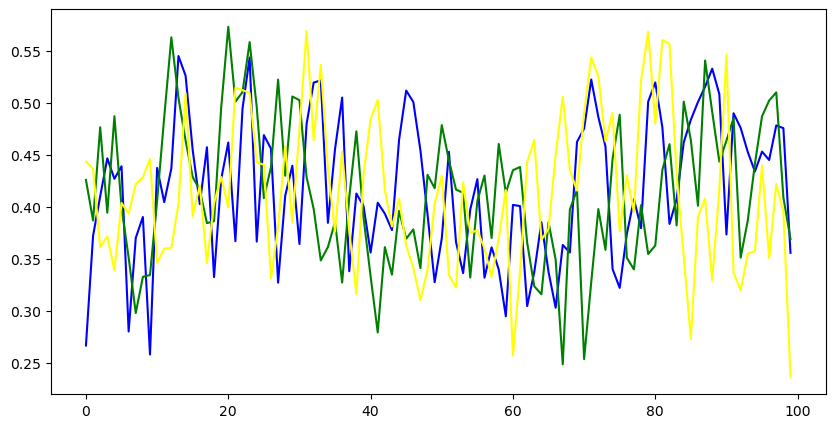

In [23]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_MC[0]['pred'][100:200], color='blue')
plt.plot(params_dict_MC[1]['pred'][100:200], color='green')
plt.plot(params_dict_MC[2]['pred'][100:200], color='yellow')
plt.show()  

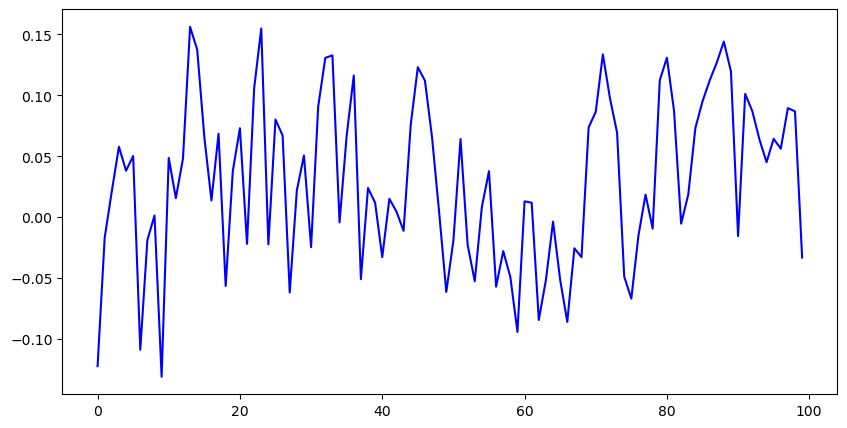

In [31]:
average_MC = np.mean(params_dict_MC[0]['pred'][100:])
difference_MC = params_dict_MC[0]['pred'] - average_MC

plt.figure(figsize=(10, 5))
plt.plot(difference_MC[100:200], color='blue')
plt.show()  


### 测试下12号

In [32]:
# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE

# seed是1000以内的随机数
seed_NARMA = np.random.randint(0, 1000, 3)
params_dict_121 = {}

# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE
for idx, i in enumerate(seed_NARMA):
    params = ReservoirParams(
            h=0.4, m0=0.008, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.01, 'gamma': 0.1293026614808925, 'Nvirt': 50}
        )

    y_test, pred = eva_narma10(params, Ntrain=2000, Ntest=1000, seed_NARMA=i)
    nrmse = NRMSE(pred,y_test)
    params_dict_121[idx] = {
        'seed_NARMA': i,
        'nrmse': nrmse,
        'y_test': y_test,
        'pred': pred
    }
    print(f"idx: {idx}, seed_NARMA: {i}, NRMSE: {nrmse}")

Seed Training: 1234
len(x_train): 2000
error with zero =  0.01297899684629399
0.010506358810666382 1.009313808227264
idx: 0, seed_NARMA: 877, NRMSE: 1.009313808227264
Seed Training: 1234
len(x_train): 2000
error with zero =  0.014693424606622952
0.011745158840569349 1.0022019403919467
idx: 1, seed_NARMA: 529, NRMSE: 1.0022019403919467
Seed Training: 1234
len(x_train): 2000
error with zero =  0.02072509060019548


KeyboardInterrupt: 

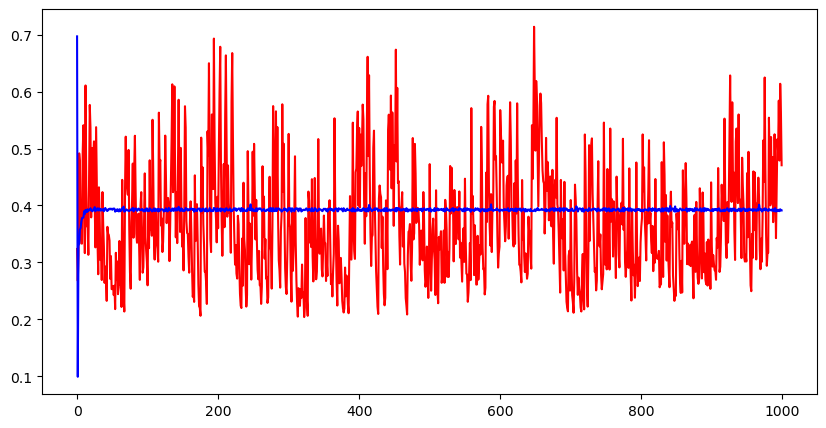

In [ ]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_121[0]['y_test'], color='red')
plt.plot(params_dict_121[0]['pred'], color='blue')
plt.show() 

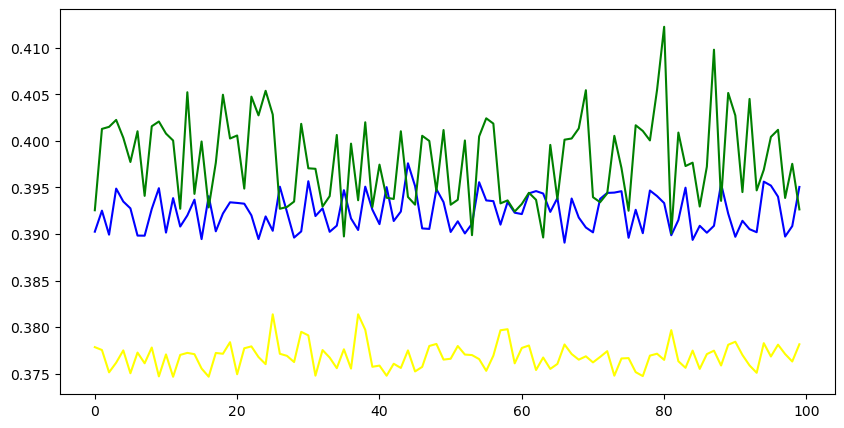

In [ ]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_121[0]['pred'][100:200], color='blue')
plt.plot(params_dict_121[1]['pred'][100:200], color='green')
plt.plot(params_dict_121[2]['pred'][100:200], color='yellow')
plt.show()

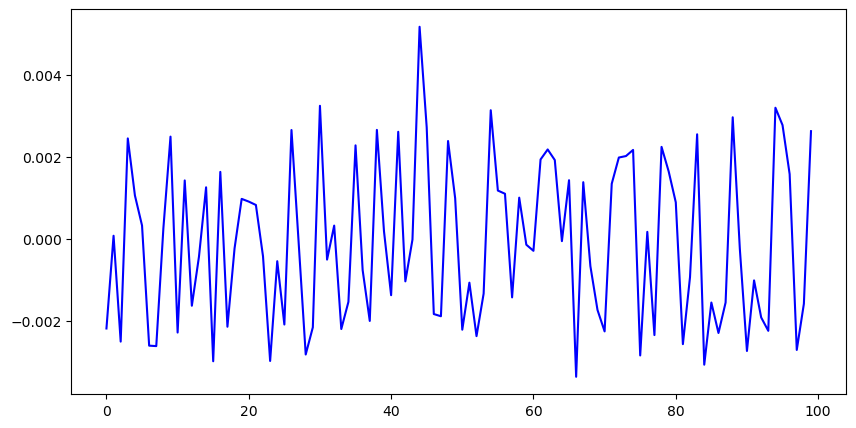

In [ ]:
average_121 = np.mean(params_dict_121[0]['pred'][100:])
difference_121 = params_dict_121[0]['pred'] - average_121

plt.figure(figsize=(10, 5))
plt.plot(difference_121[100:200], color='blue')
plt.show()  


#### 测试下cq_mc_pareto_beta50中的no.33

In [41]:
# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE

# seed是1000以内的随机数
seed_NARMA = np.random.randint(0, 1000, 3)
params_dict_beta50_33 = {}

# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE
for idx, i in enumerate(seed_NARMA):
    params = ReservoirParams(
            h=0.4, m0=0.17389499595223099, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.2, 'gamma': 0.09431886362115637, 'Nvirt': 50}
        )

    y_test, pred = eva_narma10(params, Ntrain=2000, Ntest=1000, seed_NARMA=i)
    nrmse = NRMSE(pred,y_test)
    params_dict_beta50_33[idx] = {
        'seed_NARMA': i,
        'nrmse': nrmse,
        'y_test': y_test,
        'pred': pred
    }
    print(f"idx: {idx}, seed_NARMA: {i}, NRMSE: {nrmse}")

Seed Training: 1234
len(x_train): 2000
error with zero =  0.010710454243955387
0.024996767954012403 1.4322463657106195
idx: 0, seed_NARMA: 391, NRMSE: 1.4322463657106195
Seed Training: 1234
len(x_train): 2000
error with zero =  0.007243323283829389
0.019904030748374223 1.3535247588908323
idx: 1, seed_NARMA: 242, NRMSE: 1.3535247588908323
Seed Training: 1234
len(x_train): 2000
error with zero =  0.008096186566083184
0.0192252573098109 1.3185625319783616
idx: 2, seed_NARMA: 294, NRMSE: 1.3185625319783616


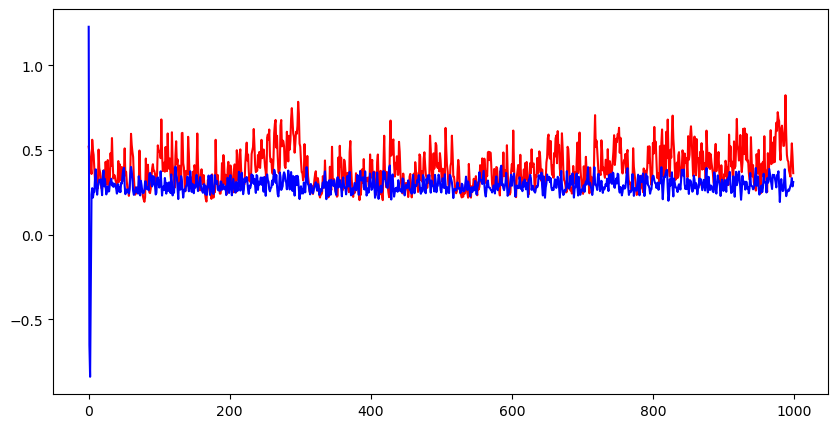

In [43]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_beta50_33[0]['y_test'], color='red')
plt.plot(params_dict_beta50_33[0]['pred'], color='blue')
plt.show() 

#### 测试下no.267

In [29]:
# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE

# seed是1000以内的随机数
seed_NARMA = np.random.randint(0, 1000, 3)
params_dict_beta50_267 = {}

# 创建一个loop，循环不同的seed_NARMA，并计算NRMSE
for idx, i in enumerate(seed_NARMA):
    params = ReservoirParams(
            h=0.4, m0=0.05165540820180517, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.2, 'gamma': 0.04802979116381437, 'Nvirt': 50}
        )

    y_test, pred = eva_narma10(params, Ntrain=2000, Ntest=1000, seed_NARMA=i)
    nrmse = NRMSE(pred,y_test)
    params_dict_beta50_267[idx] = {
        'seed_NARMA': i,
        'nrmse': nrmse,
        'y_test': y_test,
        'pred': pred
    }
    print(f"idx: {idx}, seed_NARMA: {i}, NRMSE: {nrmse}")

NameError: name 'spnc_narma10' is not defined

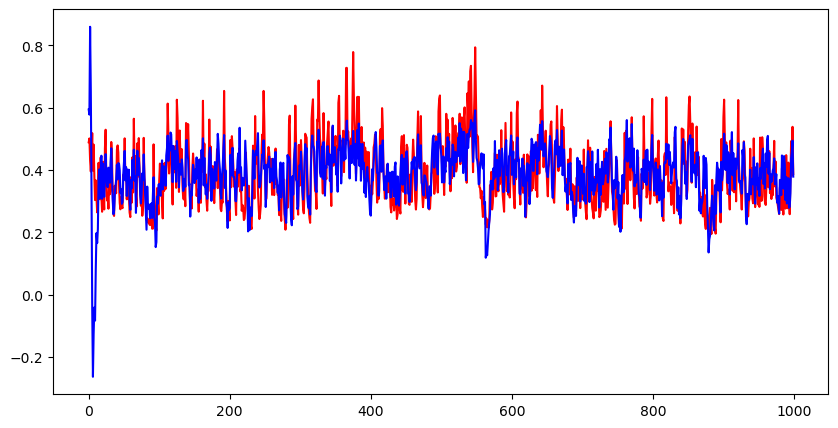

In [ ]:
plt.figure(figsize=(10, 5))

# params_dict中第一个的y_test和pred
plt.plot(params_dict_beta50_267[0]['y_test'], color='red')
plt.plot(params_dict_beta50_267[0]['pred'], color='blue')
plt.show() 

02/09/25: 经过与Tom的讨论，我们已经也可以确定'highCQ'与'task performance' 的错配可能来自于CQ的计算。

假设：在Ian的代码中，我选择了不合适的参数导致CQ的计算值有误。
验证：更加细致地理解CQ的计算。

In [30]:
# 直观地对比bestMC和bestCQ的差异
params_bestCQ = ReservoirParams(
            h=0.4, m0=0.00636114267244565, Nvirt=200, beta_prime=27.5044435911311,
            params={'theta': 0.01, 'gamma': 0.308759977781925, 'Nvirt': 200}
        )

params_bestMC = ReservoirParams(
            h=0.4, m0=0.008, Nvirt=200, beta_prime=	50.0,
            params={'theta': 0.156493838858319, 'gamma': 0.0460842584494091, 'Nvirt': 200}
        )  
print('#########################')
print('bestCQ')       
KR_bestCQ, GR_bestCQ, GR_states_bestCQ, KR_states_bestCQ, outputs_bestCQ, States_bestCQ, Normalized_States_bestCQ = evaluate_KRandGR(params_bestCQ, threshold=0.001)
print('KR_bestCQ, GR_bestCQ', KR_bestCQ, GR_bestCQ)
print('#########################')

print('#########################')
print('bestMC')
KR_bestMC, GR_bestMC, GR_states_bestMC, KR_states_bestMC, outputs_bestMC, States_bestMC, Normalized_States_bestMC = evaluate_KRandGR(params_bestMC, threshold=0.001)
print('KR_bestMC, GR_bestMC', KR_bestMC, GR_bestMC)
print('#########################')





#########################
bestCQ
KR_bestCQ, GR_bestCQ 200 1
#########################
#########################
bestMC
KR_bestMC, GR_bestMC 158 32
#########################


shape of outputs_bestCQ (200, 20, 200)
(20, 200)
max of outputs_bestCQ_array 0.005080107141475998
min of outputs_bestCQ_array -0.867927831808759
max of outputs_bestMC_array 0.15819706530320526
min of outputs_bestMC_array -0.17288046298322818


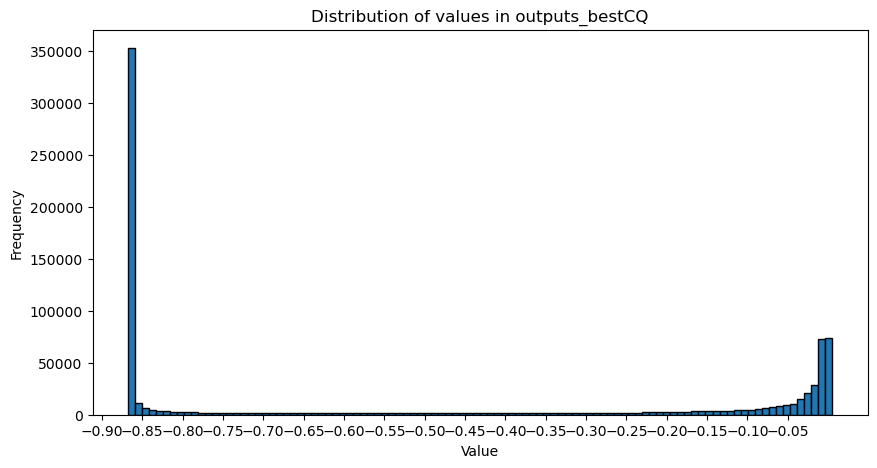

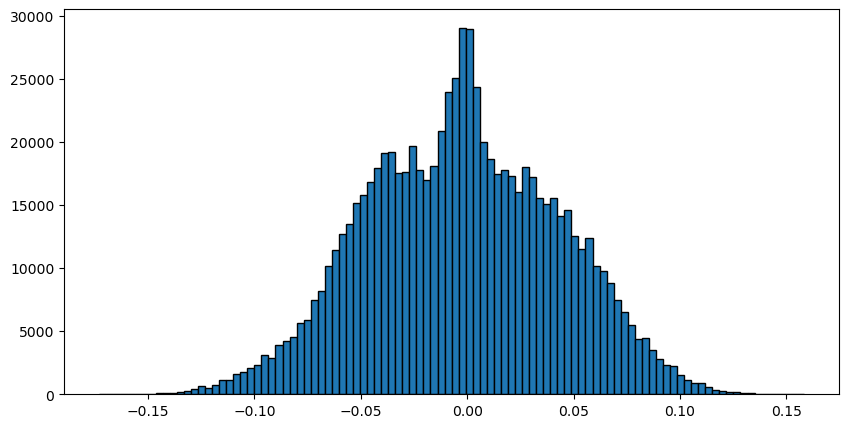

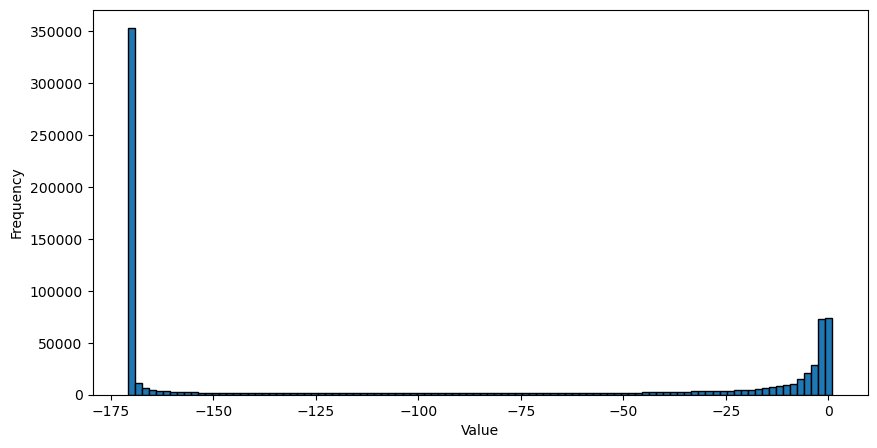

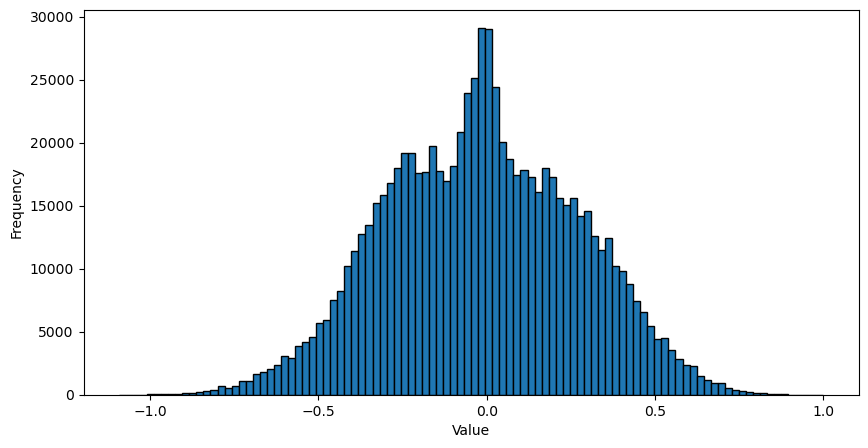

In [31]:
print('shape of outputs_bestCQ',np.shape(outputs_bestCQ))
print(np.shape(outputs_bestCQ[1]))

# 我想了解outputs_bestCQ中的元素数值分布，请用柱状图来表示元素的数值分布
# 将list转成numpy数组
outputs_bestCQ_array = np.array(outputs_bestCQ)
outputs_bestMC_array = np.array(outputs_bestMC)

# 打印出outputs_bestCQ_array的最大值和最小值
print('max of outputs_bestCQ_array',np.max(outputs_bestCQ_array))
print('min of outputs_bestCQ_array',np.min(outputs_bestCQ_array))

# 打印出outputs_bestMC_array的最大值和最小值
print('max of outputs_bestMC_array',np.max(outputs_bestMC_array))
print('min of outputs_bestMC_array',np.min(outputs_bestMC_array))



plt.figure(figsize=(10, 5))
plt.hist(outputs_bestCQ_array.flatten(), bins=100, edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Value')
# x轴的刻度尺再细一点
plt.xticks(np.arange(-0.9, 0, 0.05))
plt.title('Distribution of values in outputs_bestCQ')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(outputs_bestMC_array.flatten(), bins=100, edgecolor='black')
# 在图上标出每个bin的数值
plt.show()

# States_bestCQ的分布
plt.figure(figsize=(10, 5))
plt.hist(Normalized_States_bestCQ.flatten(), bins=100, edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Value')
plt.show()

# States_bestMC的分布
plt.figure(figsize=(10, 5))
plt.hist(Normalized_States_bestMC.flatten(), bins=100, edgecolor='black')
plt.ylabel('Frequency')
plt.xlabel('Value')
plt.show()





我可以打印出KR和GR时刻储层的状态，来对比

GR_states_bestCQ [[-170.7557723  -170.57963811 -170.58230644 ... -170.56190265
  -170.73839685 -170.73607941]
 [-170.75577231 -170.57963812 -170.58230645 ... -170.56190265
  -170.73839685 -170.73607941]
 [-170.75577231 -170.57963812 -170.58230644 ... -170.56190265
  -170.73839685 -170.73607941]
 ...
 [-170.7557723  -170.57963811 -170.58230644 ... -170.56190265
  -170.73839685 -170.73607941]
 [-170.75577232 -170.57963813 -170.58230646 ... -170.56190265
  -170.73839685 -170.73607941]
 [-170.7557725  -170.5796383  -170.58230663 ... -170.56190267
  -170.73839687 -170.73607943]]
shape of GR_states_bestCQ (200, 200)


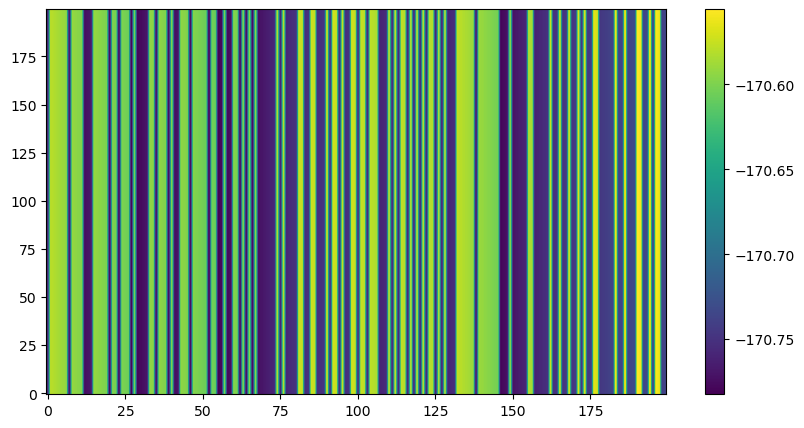

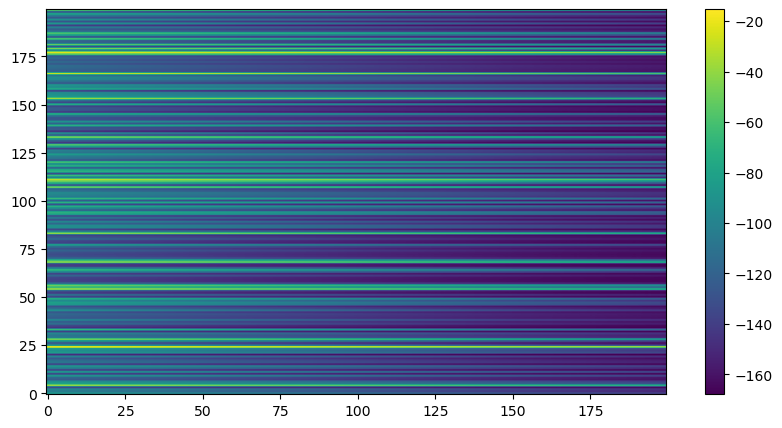

In [32]:
print('GR_states_bestCQ',GR_states_bestCQ)
print('shape of GR_states_bestCQ',np.shape(GR_states_bestCQ))

# 画一个原始热力图
plt.figure(figsize=(10, 5))
plt.imshow(GR_states_bestCQ, aspect='auto')
#翻转y轴
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(KR_states_bestCQ, aspect='auto')
#翻转y轴
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()




GR_states_bestMC [[0.35481439 0.28943896 0.22419118 ... 0.1885754  0.25107323 0.3111754 ]
 [0.35686908 0.29122725 0.22569681 ... 0.19100693 0.25343504 0.31345143]
 [0.35483484 0.28890301 0.2230895  ... 0.19130331 0.25352978 0.31333885]
 ...
 [0.35379709 0.28850043 0.22333958 ... 0.18764692 0.25015098 0.31026555]
 [0.35669669 0.2910323  0.22547942 ... 0.19102622 0.25343727 0.31343655]
 [0.35413727 0.28886247 0.22372121 ... 0.1877287  0.25025355 0.31038866]]
shape of GR_states_bestMC (200, 200)


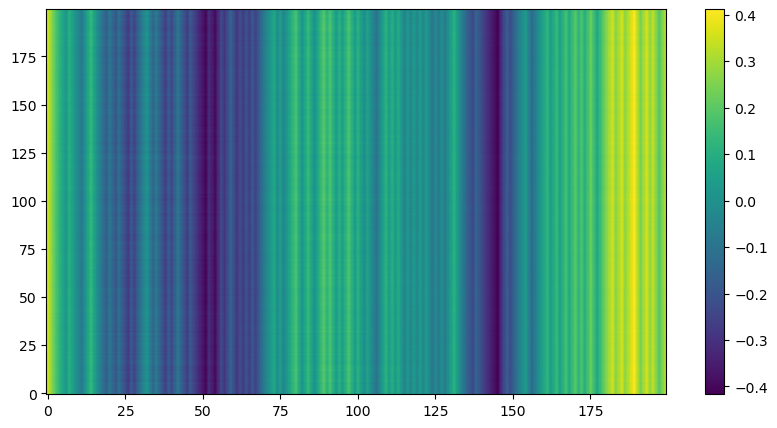

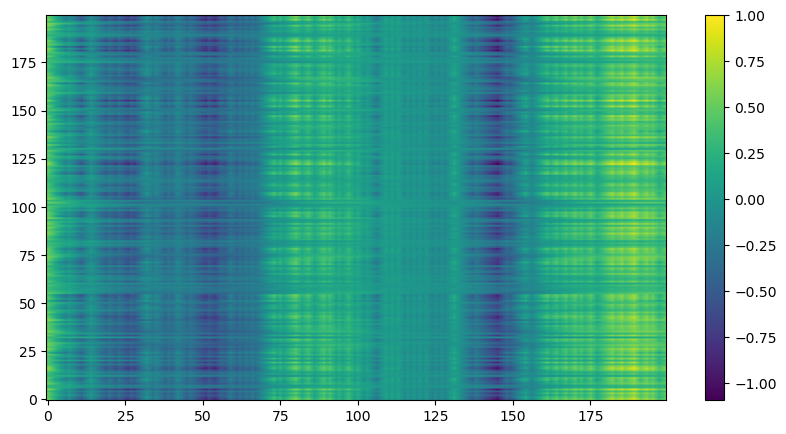

In [33]:
print('GR_states_bestMC',GR_states_bestMC)
print('shape of GR_states_bestMC',np.shape(GR_states_bestMC))

# 画一个原始热力图
plt.figure(figsize=(10, 5))
plt.imshow(GR_states_bestMC, aspect='auto')
#翻转y轴
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(KR_states_bestMC, aspect='auto')
#翻转y轴
plt.gca().invert_yaxis()
plt.colorbar()
plt.show()


如果不使用均一化，看看bestMC和bestCQ的KR和GR有什么改变？

In [35]:
# 直观地对比bestMC和bestCQ的差异
params_bestCQ = ReservoirParams(
            h=0.4, m0=0.00636114267244565, Nvirt=50, beta_prime=27.5044435911311,
            params={'theta': 0.01, 'gamma': 0.308759977781925, 'Nvirt': 50}
        )

params_bestMC = ReservoirParams(
            h=0.4, m0=0.008, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.156493838858319, 'gamma': 0.0460842584494091, 'Nvirt': 50}
        )  
print('#########################')
print('bestCQ')       
KR_bestCQ_without_normalization, GR_bestCQ_without_normalization, GR_states_bestCQ_without_normalization, KR_states_bestCQ_without_normalization, outputs_bestCQ_without_normalization, States_bestCQ_without_normalization, _ = evaluate_KRandGR(params_bestCQ, threshold=0.001)
print('KR_bestCQ without normalization, GR_bestCQ without normalization', KR_bestCQ_without_normalization, GR_bestCQ_without_normalization)
print('#########################')

print('#########################')
print('bestMC')
KR_bestMC_without_normalization, GR_bestMC_without_normalization, GR_states_bestMC_without_normalization, KR_states_bestMC_without_normalization, outputs_bestMC_without_normalization, States_bestMC_without_normalization, _ = evaluate_KRandGR(params_bestMC, threshold=0.001)
print('KR_bestMC without normalization, GR_bestMC without normalization', KR_bestMC_without_normalization, GR_bestMC_without_normalization)
print('#########################')

#########################
bestCQ
KR_bestCQ without normalization, GR_bestCQ without normalization 4 2
#########################
#########################
bestMC
KR_bestMC without normalization, GR_bestMC without normalization 8 3
#########################


threashold = 0.1呢

In [28]:
# 直观地对比bestMC和bestCQ的差异
params_bestCQ = ReservoirParams(
            h=0.4, m0=0.00636114267244565, Nvirt=50, beta_prime=27.5044435911311,
            params={'theta': 0.01, 'gamma': 0.308759977781925, 'Nvirt': 50}
        )

params_bestMC = ReservoirParams(
            h=0.4, m0=0.008, Nvirt=50, beta_prime=	50.0,
            params={'theta': 0.156493838858319, 'gamma': 0.0460842584494091, 'Nvirt': 50}
        )  
print('#########################')
print('bestCQ')       
KR_bestCQ_wn_01, GR_bestCQ_wn_01, GR_states_bestCQ_wn_01, KR_states_bestCQ_wn_01, outputs_bestCQ_wn_01, States_bestCQ_wn_01, _ = evaluate_KRandGR(params_bestCQ, threshold=0.1)
print('KR_bestCQ without normalization, GR_bestCQ without normalization', KR_bestCQ_wn_01, GR_bestCQ_wn_01)
print('#########################')

print('#########################')
print('bestMC')
KR_bestMC_wn_01, GR_bestMC_wn_01, GR_states_bestMC_wn_01, KR_states_bestMC_wn_01, outputs_bestMC_wn_01, States_bestMC_wn_01, _ = evaluate_KRandGR(params_bestMC, threshold=0.1)
print('KR_bestMC without normalization, GR_bestMC without normalization', KR_bestMC_wn_01, GR_bestMC_wn_01)
print('#########################')

#########################
bestCQ
KR_bestCQ without normalization, GR_bestCQ without normalization 1 1
#########################
#########################
bestMC
KR_bestMC without normalization, GR_bestMC without normalization 3 1
#########################
